In [1]:
# IMPORTS

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)  # was blanket 'ignore' — now only silences FutureWarning noise

import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'   # + seeds below: reduces (doesn't fully eliminate) GPU nondeterminism

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

os.makedirs("plots", exist_ok=True)

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
)

import xgboost as xgb
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, LSTM, Bidirectional, GRU
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

d:\Projects Files\Stock Market Model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Only for Colab

try:
    from google.colab import files
    print("Running in Google Colab — please upload Trainset.xlsx and Testset.xlsx:")
    files.upload()
except ImportError:
    print("Not running in Colab — skipping upload. "
          "Make sure Trainset.xlsx and Testset.xlsx are in the working directory.")

Not running in Colab — skipping upload. Make sure Trainset.xlsx and Testset.xlsx are in the working directory.


In [3]:
# Working directory path for Trainset/Testset Excel files

import os
os.chdir(os.path.join(os.path.dirname(os.getcwd()), 'data'))

In [4]:
#1.  LOAD DATA

train_data = pd.read_excel('Trainset.xlsx')
test_data  = pd.read_excel('Testset.xlsx')

required = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for label, df in [('Trainset.xlsx', train_data), ('Testset.xlsx', test_data)]:
    missing = [c for c in required if c not in df.columns]
    assert not missing, f"Missing columns in {label}: {missing}"

print(f"Train : {train_data.shape}  |  Test : {test_data.shape}")
print(train_data.head())

Train : (1259, 7)  |  Test : (125, 7)
        Date        Open        High         Low       Close   Adj Close  \
0 2013-01-02  357.385559  361.151062  355.959839  359.288177  359.288177   
1 2013-01-03  360.122742  363.600128  358.031342  359.496826  359.496826   
2 2013-01-04  362.313507  368.339294  361.488861  366.600616  366.600616   
3 2013-01-07  365.348755  367.301056  362.929504  365.001007  365.001007   
4 2013-01-08  365.393463  365.771027  359.874359  364.280701  364.280701   

    Volume  
0  5115500  
1  4666500  
2  5562800  
3  3332900  
4  3373900  


In [5]:
#2.  TECHNICAL INDICATORS
# Record lengths before combining

train_len    = len(train_data)
combined_len = train_len + len(test_data)

combined = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

# Chronological-order sanity check (only runs if a Date column exists)
if 'Date' in combined.columns:
    dates = pd.to_datetime(combined['Date'])
    assert dates.is_monotonic_increasing, (
        "Dates are not sorted ascending — indicator/lookback logic assumes "
        "train_data is immediately followed by test_data in time."
    )
else:
    print("WARNING: no 'Date' column found — chronological ordering of "
          "train_data -> test_data is assumed, not verified.")

# Raw price-based indicators (intermediate only — never used directly as model features, only as inputs to the stationary transforms below)
delta    = combined['Close'].diff()
gain     = delta.where(delta > 0, 0)
loss     = -delta.where(delta < 0, 0)
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs       = avg_gain / avg_loss.replace(0, 1e-10)          # fixes div-by-zero -> NaN RSI
combined['RSI'] = 100 - (100 / (1 + rs))

ema12 = combined['Close'].ewm(span=12, adjust=False).mean()
ema26 = combined['Close'].ewm(span=26, adjust=False).mean()
combined['MACD']        = ema12 - ema26
combined['MACD_Signal'] = combined['MACD'].ewm(span=9, adjust=False).mean()

rolling_mean = combined['Close'].rolling(20).mean()
rolling_std  = combined['Close'].rolling(20).std()
combined['BB_Upper'] = rolling_mean + 2 * rolling_std
combined['BB_Lower'] = rolling_mean - 2 * rolling_std

# Stationary / bounded transforms — these ARE the model features
prev_close = combined['Close'].shift(1)

combined['Open_ret']  = (combined['Open']  - prev_close) / prev_close
combined['High_ret']  = (combined['High']  - prev_close) / prev_close
combined['Low_ret']   = (combined['Low']   - prev_close) / prev_close
combined['Close_ret'] = (combined['Close'] - prev_close) / prev_close

combined['Volume_log'] = np.log1p(combined['Volume'])

combined['MACD_norm']        = combined['MACD'] / combined['Close']
combined['MACD_Signal_norm'] = combined['MACD_Signal'] / combined['Close']

bb_width = (combined['BB_Upper'] - combined['BB_Lower']).replace(0, 1e-10)  # guard flat-price div-by-zero
combined['BB_PctB'] = (combined['Close'] - combined['BB_Lower']) / bb_width

# dropna clears indicator warm-up rows (RSI/BB windows) + the single .shift(1)
# lag row — all at the very start (train side), same as before
combined.dropna(inplace=True)
combined.reset_index(drop=True, inplace=True)

rows_dropped  = combined_len - len(combined)
new_train_len = train_len - rows_dropped

train_data = combined.iloc[:new_train_len].reset_index(drop=True)
test_data  = combined.iloc[new_train_len:].reset_index(drop=True)

print(f"Rows dropped to warm up indicators: {rows_dropped}")
print(f"Train : {train_data.shape}  |  Test : {test_data.shape}")

Rows dropped to warm up indicators: 19
Train : (1240, 20)  |  Test : (125, 20)


In [6]:
#3.  FEATURES & CONSTANTS

FEATURES = [
    'Open_ret', 'High_ret', 'Low_ret', 'Close_ret',
    'Volume_log', 'RSI', 'MACD_norm', 'MACD_Signal_norm', 'BB_PctB'
]
TARGET_COL = FEATURES.index('Close_ret')    # target is a return for every model now
SEQ_LEN    = 60
N_FEAT     = len(FEATURES)

NN_FEATURES = ['Close_ret', 'Volume_log', 'RSI', 'MACD_norm', 'MACD_Signal_norm']
nn_indices  = [FEATURES.index(f) for f in NN_FEATURES]
N_FEAT_NN   = len(NN_FEATURES)

In [7]:
#4.  TRAIN/VALIDATION SPLIT

split_idx = int(0.8 * len(train_data))

train_df = train_data.iloc[:split_idx]
val_df   = train_data.iloc[split_idx:]

print(f"Train rows : {train_df.shape}")
print(f"Val rows   : {val_df.shape}")

Train rows : (992, 20)
Val rows   : (248, 20)


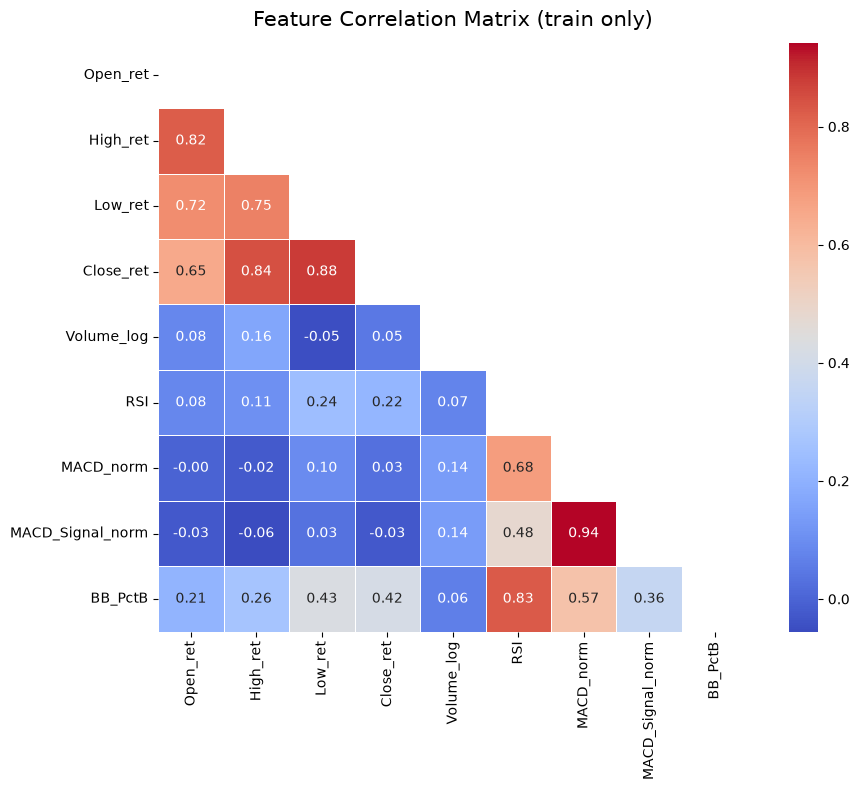

In [8]:
#5.  EDA: CORRELATION HEATMAP

plt.figure(figsize=(10, 8))
corr = train_df[FEATURES].corr()          # was train_data — included val rows before the split existed
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, square=True, linewidths=0.5, annot_kws={'size': 10}
)
plt.title('Feature Correlation Matrix (train only)', fontsize=15, pad=12)
plt.tight_layout()
plt.savefig("plots/01_correlation_heatmap_eda.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
#6.  NORMALIZATION

scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_df[FEATURES].values)
train_scaled = scaler.transform(train_df[FEATURES].values)

In [10]:
#7.  SEQUENCE BUILDER

def build_sequences(data, seq_len):
    """Sliding windows of length seq_len. Target = data[i, TARGET_COL] (scaled)."""
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len:i])
        y.append(data[i, TARGET_COL])
    return np.array(X), np.array(y)

def build_raw_targets(series, seq_len):
    """
    Unscaled counterpart of build_sequences()'s target, aligned row-for-row.
    `series` must be the raw Close_ret values in the same row order as the
    array passed to build_sequences(). Replaces the old build_return_targets()
    — Close_ret already IS the return, so no separate recomputation is needed.
    Used directly by XGBoost / RF / Linear Regression, unifying all three
    (and, via inverse_return, the NNs too) onto the same target quantity.
    """
    return np.asarray(series)[seq_len:]

#  Training sequences 
X_train, y_train = build_sequences(train_scaled, SEQ_LEN)
X_train_nn = X_train[:, :, nn_indices]

y_train_ret = build_raw_targets(train_df['Close_ret'].values, SEQ_LEN)

#  Validation sequences
val_inputs = pd.concat(
    (train_df[FEATURES].tail(SEQ_LEN), val_df[FEATURES]), axis=0
).reset_index(drop=True)                      # avoids duplicate-index concat

val_scaled_full = scaler.transform(val_inputs.values)
X_val, y_val = build_sequences(val_scaled_full, SEQ_LEN)
X_val_nn = X_val[:, :, nn_indices]

y_val_ret = build_raw_targets(val_inputs['Close_ret'].values, SEQ_LEN)

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape} | y_val   : {y_val.shape}")
print(f"y_train_ret : {y_train_ret.shape} | y_val_ret : {y_val_ret.shape}")
print(f"X_train_nn : {X_train_nn.shape} | X_val_nn : {X_val_nn.shape}")

X_train : (932, 60, 9) | y_train : (932,)
X_val   : (248, 60, 9) | y_val   : (248,)
y_train_ret : (932,) | y_val_ret : (248,)
X_train_nn : (932, 60, 5) | X_val_nn : (248, 60, 5)


In [11]:
#8.  HELPERS

def early_stop():
    return EarlyStopping(monitor='val_loss', patience=20,
                          restore_best_weights=True, verbose=1)

def checkpoint(filename):
    return ModelCheckpoint(filename, monitor='val_loss',
                            save_best_only=True, verbose=1)

def reduce_lr():
    return ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                              patience=10, min_lr=1e-6, verbose=1)

def inverse_return(scaled_preds, scaler=scaler, n_feat=N_FEAT, target_col=TARGET_COL):
    """Invert MinMax scaling on a predicted TARGET_COL (Close_ret) value."""
    dummy = np.zeros((len(scaled_preds), n_feat))
    dummy[:, target_col] = scaled_preds
    return scaler.inverse_transform(dummy)[:, target_col]

def predict_returns(model, X, flatten_output=True):
    """NN models only: predict scaled return, then invert to a raw return."""
    raw = model.predict(X, verbose=0)          
    if flatten_output:
        raw = raw.flatten()
    return inverse_return(raw)

def reconstruct_from_returns(pred_returns, prev_closes):
    """prev_closes[i] = actual close price the day before prediction i."""
    return prev_closes * (1 + pred_returns)

def directional_accuracy(real, pred):
    real_dir = np.diff(real) > 0
    pred_dir = np.diff(pred) > 0
    return np.mean(real_dir == pred_dir) * 100

MODEL_COLORS = {
    'BiLSTM':   'royalblue',
    'GRU':      'seagreen',
    'XGBoost':  'crimson',
    'Linear Regression': 'purple',
    'Random Forest': 'brown',
    'Ensemble': 'gold'
}

os.makedirs("models", exist_ok=True)   # checkpoints save to a real subfolder, not cwd

In [12]:
#9.  BI-LSTM

print("\n" + "="*50)
print("  Training  :  Bidirectional LSTM")
print("="*50)

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(SEQ_LEN, N_FEAT_NN)),
    Dropout(0.2),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(64)),
    Dropout(0.2),
    Dense(1)
], name='BiLSTM')
model_bilstm.compile(optimizer='adam', loss='mse')
model_bilstm.summary()

history_bilstm = model_bilstm.fit(
    X_train_nn, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_nn, y_val),
    callbacks=[early_stop(), checkpoint("models/best_bilstm.keras"), reduce_lr()],
    verbose=1
)


  Training  :  Bidirectional LSTM


d:\Projects Files\Stock Market Model\.venv\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 60, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 233,601 (912.50 KB)

 Trainable params: 233,601 (912.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0216
Epoch 1: val_loss improved from None to 0.00214, saving model to models/best_bilstm.keras

Epoch 1: finished saving model to models/best_bilstm.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - loss: 0.0113 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0059
Epoch 2: val_loss did not improve from 0.00214
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0057 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0059
Epoch 3: val_loss did not improve from 0.00214
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - loss: 0.0055 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 4/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0056
Epoch 4: val_loss did not improve from 0.00214
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 0.0054 - val_loss: 0.0024 - learning_rate: 0.0010
Epoch 5/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/

In [13]:
#10.  GRU

print("\n" + "="*50)
print("  Training  :  GRU")
print("="*50)

model_gru = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, N_FEAT_NN)),
    Dropout(0.2),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(64),
    Dropout(0.2),
    Dense(1)
], name='GRU')
model_gru.compile(optimizer='adam', loss='mse')
model_gru.summary()

history_gru = model_gru.fit(
    X_train_nn, y_train,
    epochs=100, batch_size=32,
    validation_data=(X_val_nn, y_val),
    callbacks=[early_stop(), checkpoint("models/best_gru.keras"), reduce_lr()],
    verbose=1
)


  Training  :  GRU


d:\Projects Files\Stock Market Model\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        13,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 60, 64)         │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        24,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,617 (248.50 KB)

 Trainable params: 63,617 (248.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - loss: 0.0219
Epoch 1: val_loss improved from None to 0.00245, saving model to models/best_gru.keras

Epoch 1: finished saving model to models/best_gru.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - loss: 0.0127 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 0.0070
Epoch 2: val_loss did not improve from 0.00245
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 165ms/step - loss: 0.0066 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.0066
Epoch 3: val_loss did not improve from 0.00245
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - loss: 0.0063 - val_loss: 0.0035 - learning_rate: 0.0010
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.0064
Epoch 4: val_loss did not improve from 0.00245
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.0063 - val_loss: 0.0029 - learning_rate: 0.0010
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 163m

In [14]:
#11.  XGBOOST

print("\n" + "="*50)
print("  Training  :  XGBoost")
print("="*50)

X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat   = X_val.reshape(len(X_val),   -1)

model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    reg_alpha=0.1,
    reg_lambda=1,
    verbosity=0,
    early_stopping_rounds=20,
)

model_xgb.fit(
    X_train_flat, y_train_ret,
    eval_set=[(X_val_flat, y_val_ret)],
    verbose=50
)

model_xgb.save_model("models/best_xgb.json")


  Training  :  XGBoost
[0]	validation_0-rmse:0.00971
[29]	validation_0-rmse:0.00971


In [15]:
#12.  LINEAR REGRESSION

print("\n" + "="*50)
print("  Training  :  Linear Regression")
print("="*50)

model_lr = LinearRegression()
model_lr.fit(X_train_flat, y_train_ret)   # trained on raw return — same target space as XGBoost/RF


  Training  :  Linear Regression


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](540,)","[ 0. , 0. ,-0. ,...,-0.79, 0.75, 0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.1583
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,540
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,540
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](540,)","[45.94,42.31,33.33,..., 0.01, 0.01, 0.01]"


In [16]:
#13.  RANDOMFOREST

print("\n" + "="*50)
print("  Training  :  Random Forest")
print("="*50)

model_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    verbose=0        
)

model_rf.fit(X_train_flat, y_train_ret)


  Training  :  Random Forest


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [17]:
#14.  PREPARE TEST SET

dataset_total = pd.concat((train_data[FEATURES], test_data[FEATURES]), axis=0).reset_index(drop=True)     # avoids duplicate-index concat

inputs = dataset_total[len(dataset_total) - len(test_data) - SEQ_LEN:].values
inputs = scaler.transform(inputs)

X_test, _ = build_sequences(inputs, SEQ_LEN)
X_test_flat = X_test.reshape(len(X_test), -1)
X_test_nn = X_test[:, :, nn_indices]

real_close = test_data['Close'].values    # raw actual price, untouched by any transform

assert len(X_test) == len(real_close), (
    f"Length mismatch: X_test has {len(X_test)} rows "
    f"but real_close has {len(real_close)} rows. "
    f"Check test_data alignment after indicator computation."
)
print(f"\nTest sequences : {X_test.shape}  |  Real prices : {real_close.shape}")
print(f"X_test_nn : {X_test_nn.shape}")


Test sequences : (125, 60, 9)  |  Real prices : (125,)
X_test_nn : (125, 60, 5)


In [19]:
#15.  PREDICTIONS

prev_closes_test = np.concatenate([
    [train_data['Close'].values[-1]],
    test_data['Close'].values[:-1]
])

prev_closes_val = np.concatenate([
    [train_df['Close'].values[-1]],   # last train close -> first val prediction
    val_df['Close'].values[:-1]
])

preds = {
    'BiLSTM':   reconstruct_from_returns(predict_returns(model_bilstm, X_test_nn), prev_closes_test),
    'GRU':      reconstruct_from_returns(predict_returns(model_gru, X_test_nn), prev_closes_test),
    'XGBoost':  reconstruct_from_returns(model_xgb.predict(X_test_flat), prev_closes_test),
    'Linear Regression': reconstruct_from_returns(model_lr.predict(X_test_flat), prev_closes_test),
    'Random Forest': reconstruct_from_returns(model_rf.predict(X_test_flat), prev_closes_test),
}

val_preds = {
    'BiLSTM':   reconstruct_from_returns(predict_returns(model_bilstm, X_val_nn), prev_closes_val),
    'GRU':      reconstruct_from_returns(predict_returns(model_gru, X_val_nn), prev_closes_val),
    'XGBoost':  reconstruct_from_returns(model_xgb.predict(X_val_flat), prev_closes_val),
    'Linear Regression': reconstruct_from_returns(model_lr.predict(X_val_flat), prev_closes_val),
    'Random Forest': reconstruct_from_returns(model_rf.predict(X_val_flat), prev_closes_val),
}

# Ground truth for validation is just the actual close price — no inverse
# scaling needed, since every model's prediction is a reconstructed price
val_real = val_df['Close'].values

val_mae   = {name: mean_absolute_error(val_real, p) for name, p in val_preds.items()}
inv_mae   = {name: 1 / mae for name, mae in val_mae.items()}
total_inv = sum(inv_mae.values())
ensemble_weights = {name: w / total_inv for name, w in inv_mae.items()}

print("\nEnsemble weights (derived from validation MAE):")
for name, w in ensemble_weights.items():
    print(f"  {name:20s} val MAE = {val_mae[name]:.4f}   weight = {w:.4f}")

preds['Ensemble'] = sum(
    ensemble_weights[name] * preds[name] for name in ensemble_weights
)


Ensemble weights (derived from validation MAE):
  BiLSTM               val MAE = 6.4670   weight = 0.2217
  GRU                  val MAE = 6.4616   weight = 0.2219
  XGBoost              val MAE = 6.4727   weight = 0.2215
  Linear Regression    val MAE = 12.3835   weight = 0.1158
  Random Forest        val MAE = 6.5487   weight = 0.2190


In [20]:
# 16.  REGRESSION METRICS

print("\n" + "="*60)
print("  REGRESSION METRICS")
print("="*60)

reg_results = {}
for name, pred in preds.items():
    rmse = np.sqrt(mean_squared_error(real_close, pred))
    mae  = mean_absolute_error(real_close, pred)
    mape = np.mean(np.abs((real_close - pred) / np.where(real_close != 0, real_close, np.nan))) * 100
    r2   = r2_score(real_close, pred)
    evs  = explained_variance_score(real_close, pred)
    da   = directional_accuracy(real_close, pred)
    reg_results[name] = dict(RMSE=rmse, MAE=mae, MAPE=mape, R2=r2, EVS=evs, DA=da)
    print(f"\n  {name}")
    print(f"    RMSE = {rmse:.4f}")
    print(f"    MAE  = {mae:.4f}")
    print(f"    MAPE = {mape:.2f} %")
    print(f"    R²   = {r2:.4f}")
    print(f"    Explained Variance = {evs:.4f}")
    print(f"    Directional Accuracy = {da:.2f} %")


  REGRESSION METRICS

  BiLSTM
    RMSE = 18.5115
    MAE  = 13.7189
    MAPE = 1.27 %
    R²   = 0.8503
    Explained Variance = 0.8508
    Directional Accuracy = 54.84 %

  GRU
    RMSE = 18.5979
    MAE  = 13.7416
    MAPE = 1.27 %
    R²   = 0.8489
    Explained Variance = 0.8494
    Directional Accuracy = 53.23 %

  XGBoost
    RMSE = 18.5639
    MAE  = 13.7339
    MAPE = 1.27 %
    R²   = 0.8495
    Explained Variance = 0.8495
    Directional Accuracy = 52.42 %

  Linear Regression
    RMSE = 31.9504
    MAE  = 24.6737
    MAPE = 2.28 %
    R²   = 0.5542
    Explained Variance = 0.5545
    Directional Accuracy = 51.61 %

  Random Forest
    RMSE = 18.4719
    MAE  = 13.6008
    MAPE = 1.26 %
    R²   = 0.8510
    Explained Variance = 0.8510
    Directional Accuracy = 54.84 %

  Ensemble
    RMSE = 18.8802
    MAE  = 13.8379
    MAPE = 1.28 %
    R²   = 0.8443
    Explained Variance = 0.8444
    Directional Accuracy = 54.84 %


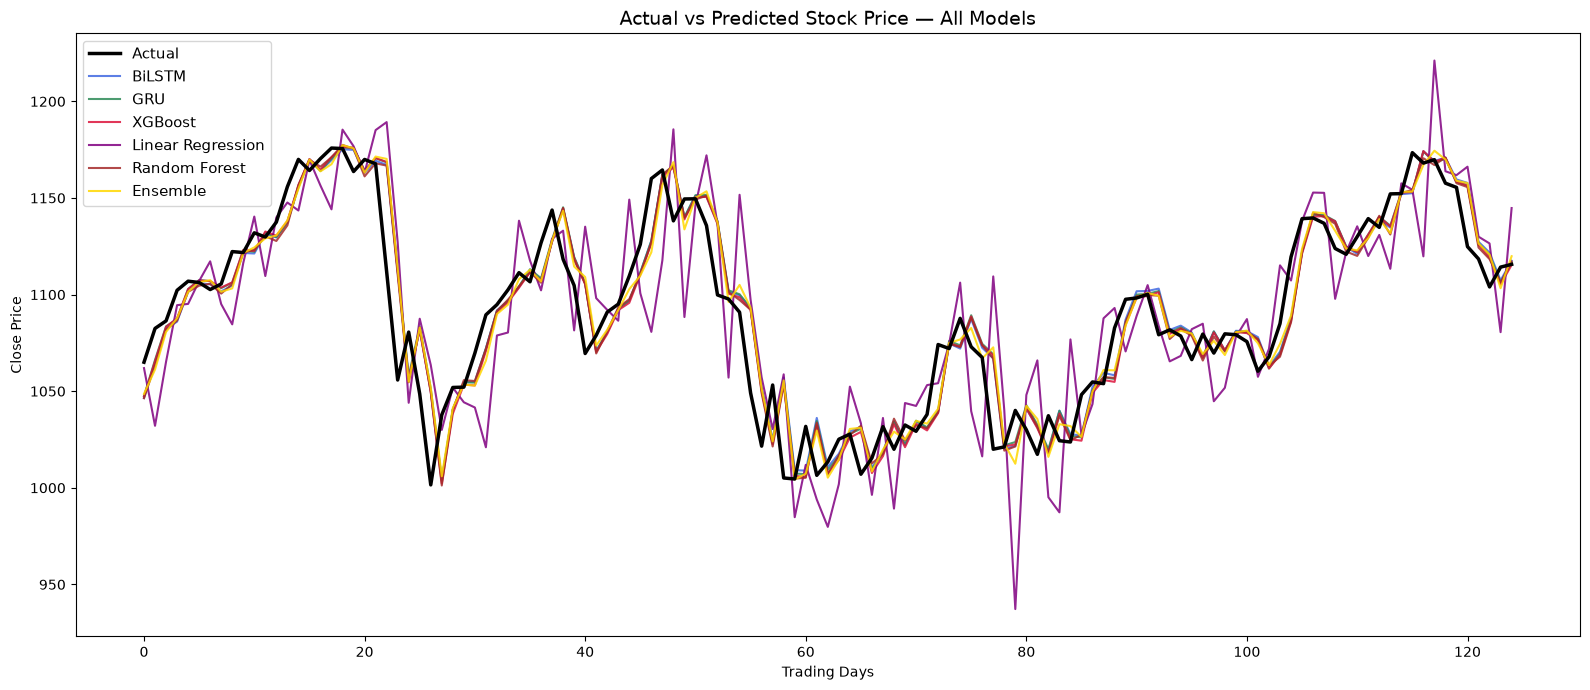

In [21]:
#17.  VISUALISATIONS
#VIZ-1

plt.figure(figsize=(16, 7))
plt.plot(real_close, label='Actual', color='black',
         linewidth=2.5, zorder=5)
for name, pred in preds.items():
    plt.plot(pred, label=name, alpha=0.85,
             color=MODEL_COLORS[name], linewidth=1.5)
plt.xlabel('Trading Days')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Stock Price — All Models', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("plots/02_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()

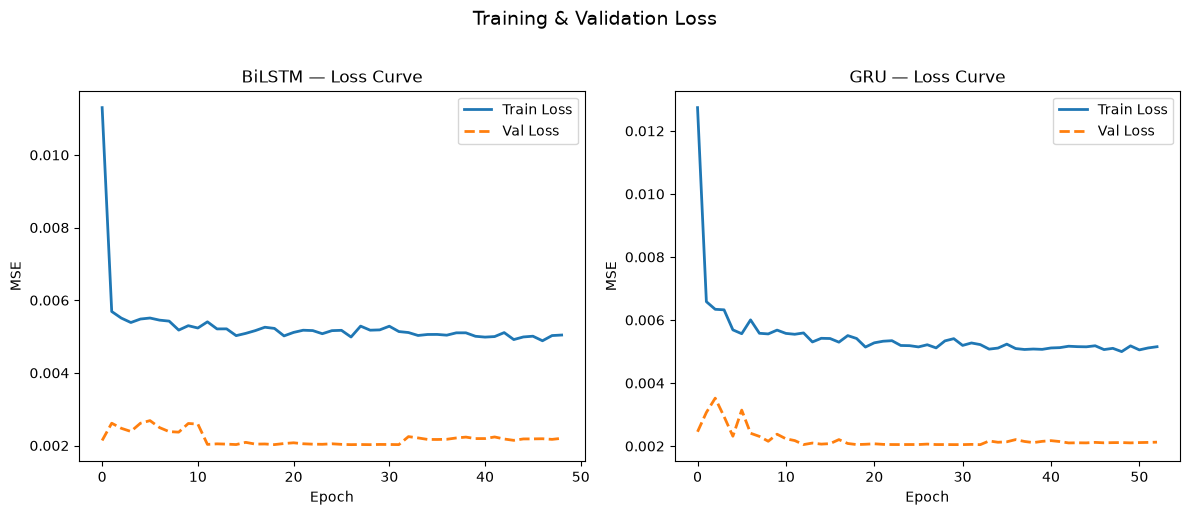

In [22]:
#VIZ-2

histories = {
    'BiLSTM':   history_bilstm,
    'GRU':      history_gru
}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'],     label='Train Loss', linewidth=2)
    ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=2,
            linestyle='--')
    ax.set_title(f'{name} — Loss Curve', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
plt.suptitle('Training & Validation Loss', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("plots/03_loss_curves.png", dpi=300, bbox_inches='tight')
plt.show()

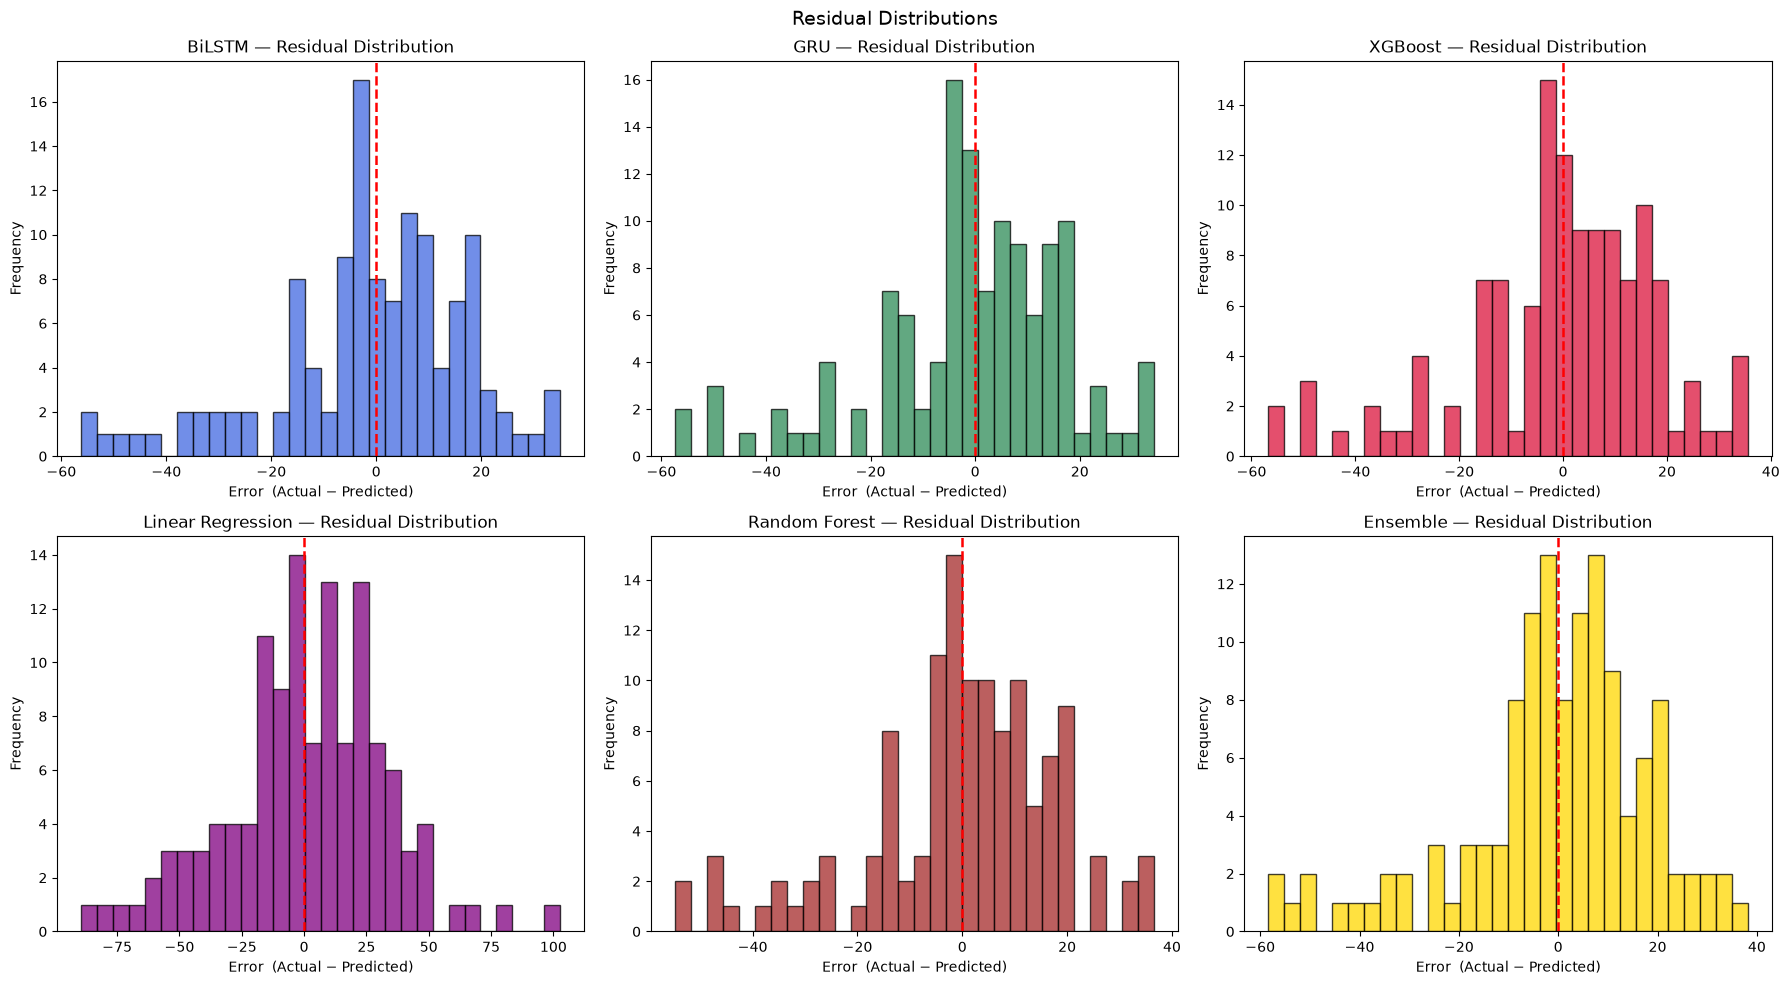

In [23]:
#VIZ-3

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (name, pred) in zip(axes, preds.items()):
    residuals = real_close - pred
    ax.hist(residuals, bins=30, color=MODEL_COLORS[name],
            edgecolor='black', alpha=0.75)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.8)
    ax.set_title(f'{name} — Residual Distribution', fontsize=12)
    ax.set_xlabel('Error  (Actual − Predicted)')
    ax.set_ylabel('Frequency')
plt.suptitle('Residual Distributions', fontsize=14)
plt.tight_layout()
plt.savefig("plots/04_residual_histograms.png", dpi=300, bbox_inches='tight')
plt.show()

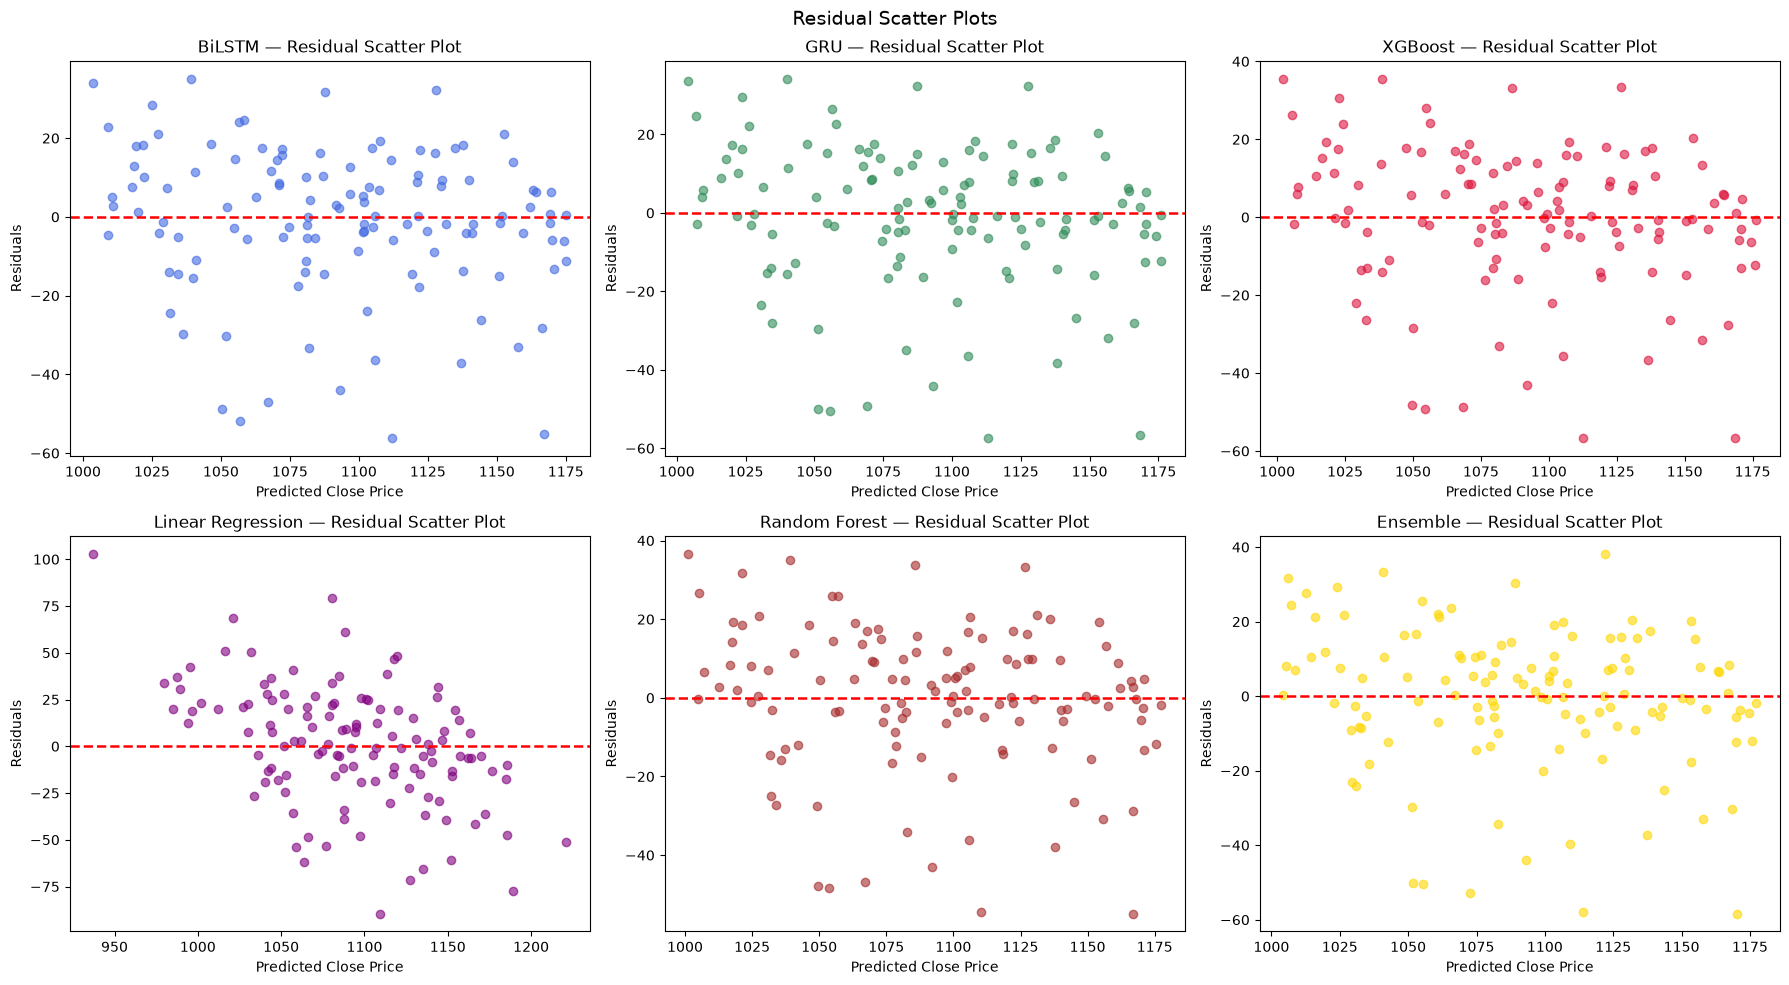

In [24]:
#VIZ-4

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, preds.items()):
    residuals = real_close - pred

    ax.scatter(pred, residuals,
               color=MODEL_COLORS[name],
               alpha=0.6)

    ax.axhline(y=0, color='red',
               linestyle='--',
               linewidth=1.8)

    ax.set_title(f'{name} — Residual Scatter Plot', fontsize=12)
    ax.set_xlabel('Predicted Close Price')
    ax.set_ylabel('Residuals')

plt.suptitle('Residual Scatter Plots', fontsize=14)
plt.tight_layout()
plt.savefig("plots/05_residual_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

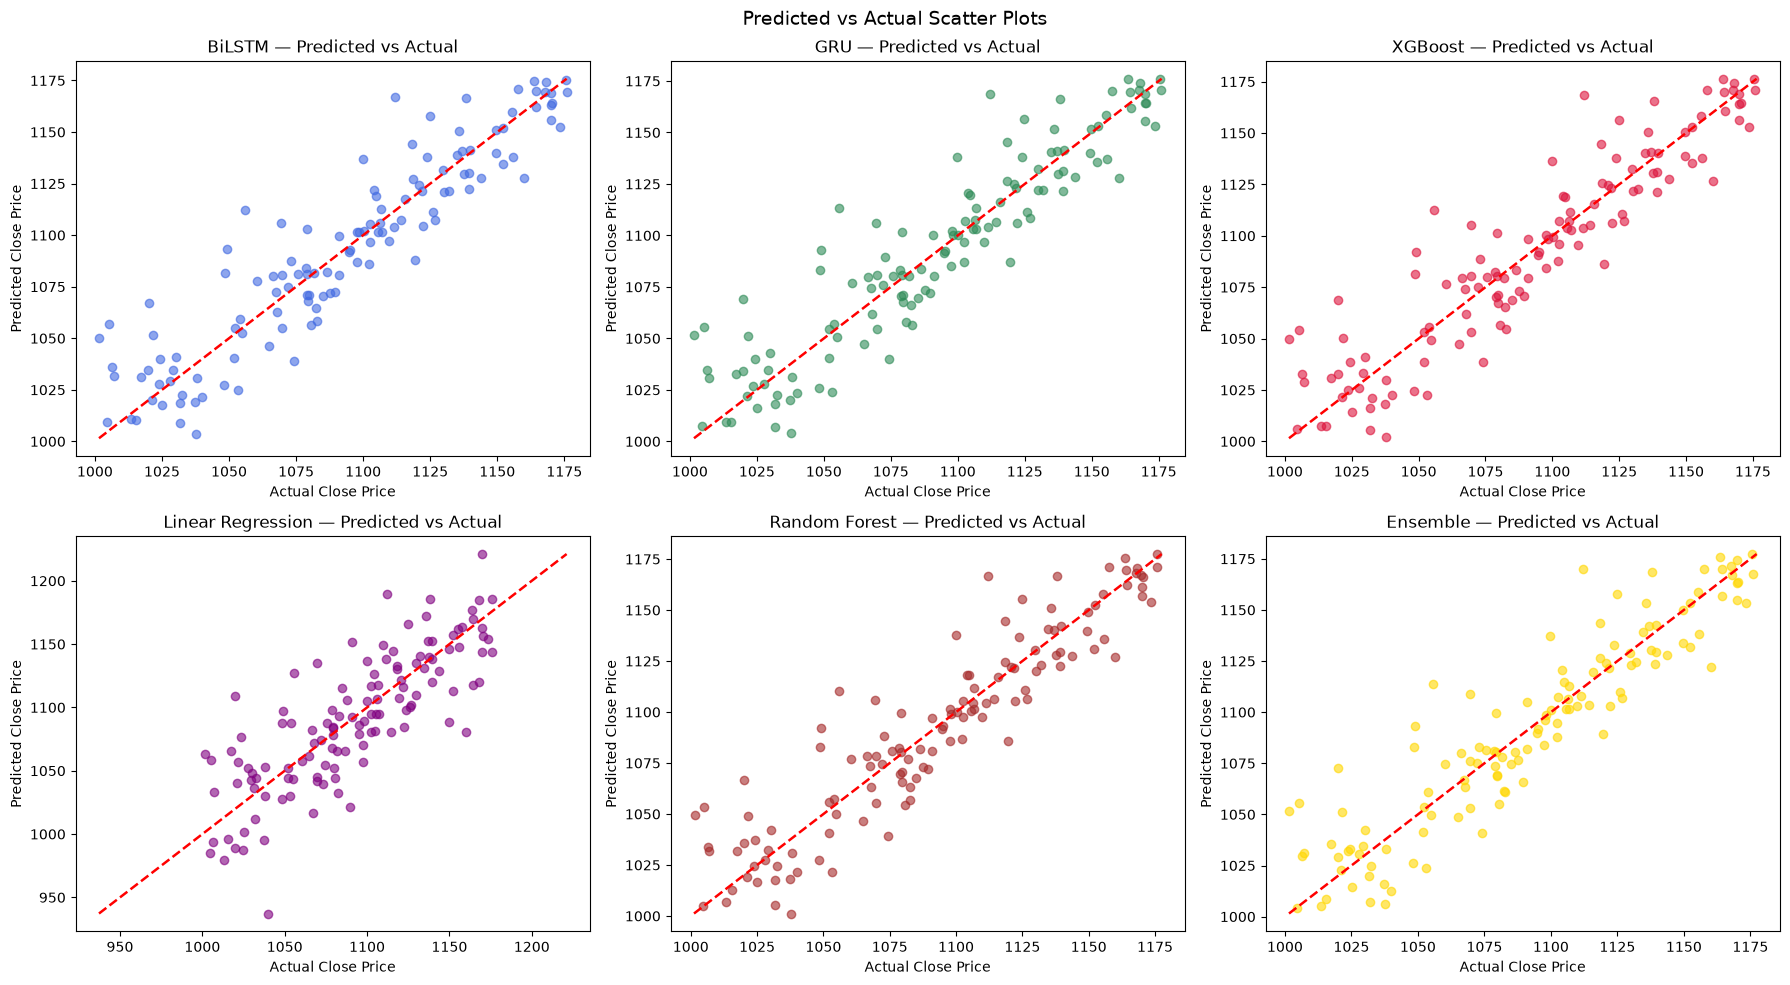

In [25]:
#VIZ-5

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, preds.items()):

    # Scatter plot
    ax.scatter(
        real_close,
        pred,
        color=MODEL_COLORS[name],
        alpha=0.6
    )

    # Perfect prediction line
    min_val = min(real_close.min(), pred.min())
    max_val = max(real_close.max(), pred.max())

    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color='red',
        linestyle='--',
        linewidth=1.8
    )

    ax.set_title(f'{name} — Predicted vs Actual', fontsize=12)
    ax.set_xlabel('Actual Close Price')
    ax.set_ylabel('Predicted Close Price')

plt.suptitle('Predicted vs Actual Scatter Plots', fontsize=14)
plt.tight_layout()
plt.savefig("plots/06_predicted_vs_actual_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

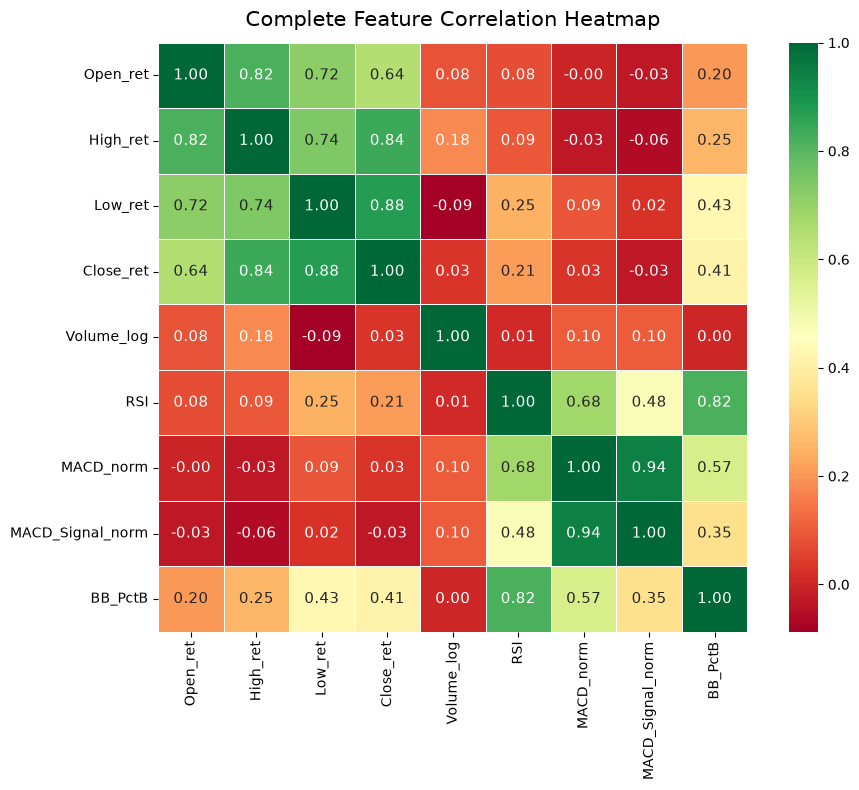

In [26]:
#VIZ-6

plt.figure(figsize=(10, 8))
sns.heatmap(
    train_data[FEATURES].corr(), annot=True, fmt='.2f',
    cmap='RdYlGn', linewidths=0.5, square=True,
    annot_kws={'size': 11}
)
plt.title('Complete Feature Correlation Heatmap', fontsize=15, pad=12)
plt.tight_layout()
plt.savefig("plots/07_correlation_heatmap_full.png", dpi=300, bbox_inches='tight')
plt.show()

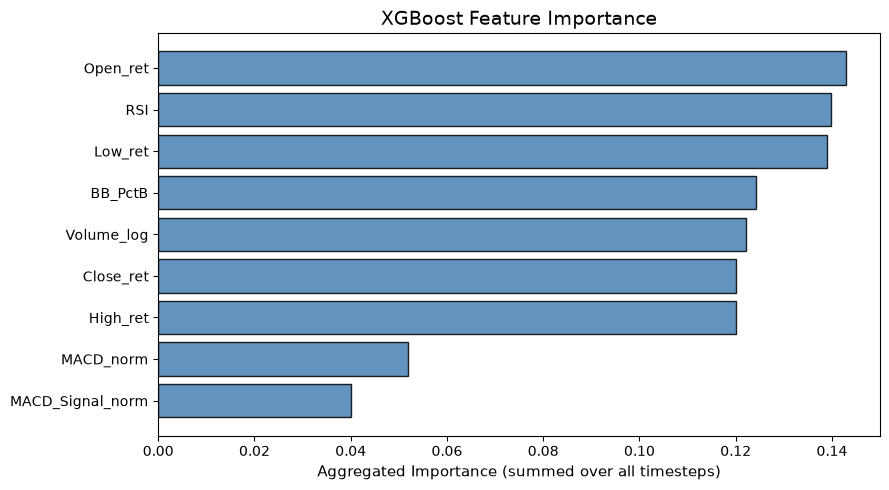

In [27]:
#VIZ-7

importances     = model_xgb.feature_importances_   # length = SEQ_LEN * N_FEAT
feat_imp_agg    = np.zeros(N_FEAT)
for idx, imp in enumerate(importances):
    feat_imp_agg[idx % N_FEAT] += imp

sorted_idx = np.argsort(feat_imp_agg)
plt.figure(figsize=(9, 5))
bars = plt.barh(
    [FEATURES[i] for i in sorted_idx],
    feat_imp_agg[sorted_idx],
    color='steelblue', edgecolor='black', alpha=0.85
)
plt.xlabel('Aggregated Importance (summed over all timesteps)', fontsize=11)
plt.title('XGBoost Feature Importance', fontsize=14)
plt.tight_layout()
plt.savefig("plots/08_xgb_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()


Generating SHAP explanations...


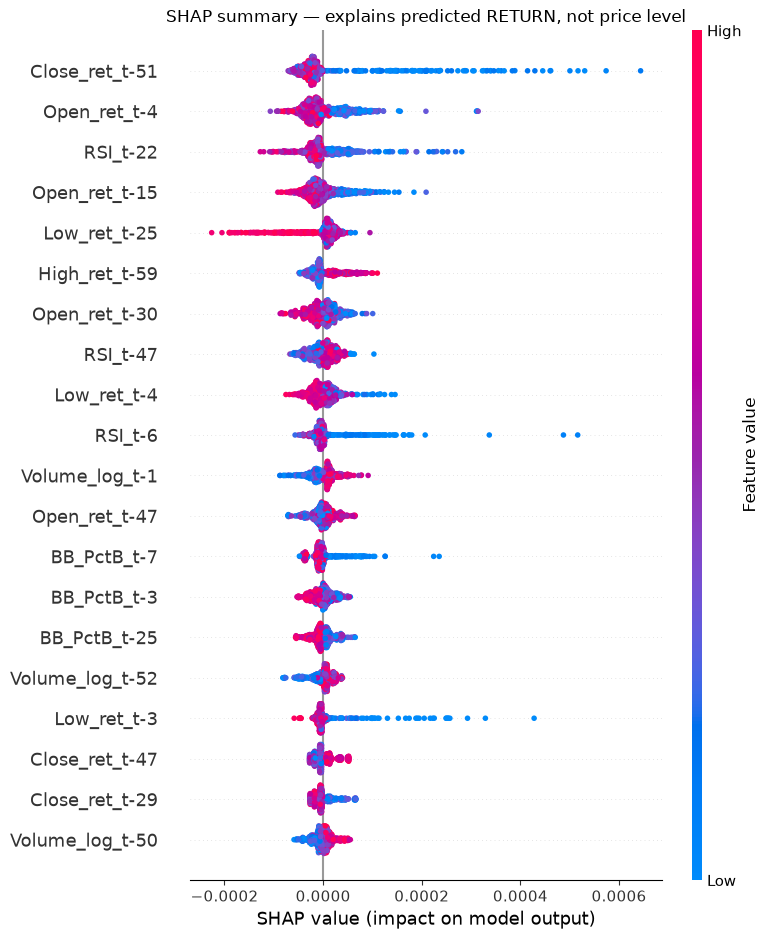

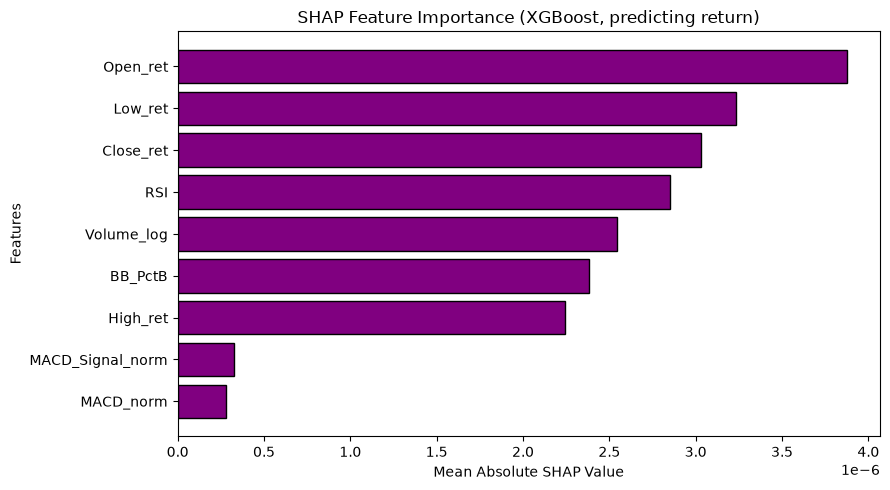

In [28]:
#VIZ-8

print("\nGenerating SHAP explanations...")

sample_size = min(1000, len(X_train_flat))
rng = np.random.default_rng(42)
shap_idx = rng.choice(len(X_train_flat), size=sample_size, replace=False)
X_shap = X_train_flat[shap_idx]      # random sample, not just the earliest rows

shap_feature_names = [
    f"{FEATURES[f]}_t-{SEQ_LEN - t}"
    for t in range(SEQ_LEN)
    for f in range(N_FEAT)
]

explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(
    shap_values, X_shap, feature_names=shap_feature_names,
    max_display=20, show=False
)
plt.title("SHAP summary — explains predicted RETURN, not price level")
plt.tight_layout()
plt.savefig("plots/09_shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

shap_agg = np.zeros(N_FEAT)
for feature_idx in range(N_FEAT):
    cols = np.arange(feature_idx, X_shap.shape[1], N_FEAT)
    shap_agg[feature_idx] = np.mean(np.abs(shap_values[:, cols]))

sorted_idx = np.argsort(shap_agg)
plt.figure(figsize=(9, 5))
plt.barh([FEATURES[i] for i in sorted_idx], shap_agg[sorted_idx],
         color='purple', edgecolor='black')
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Features")
plt.title("SHAP Feature Importance (XGBoost, predicting return)")
plt.tight_layout()
plt.savefig("plots/10_shap_feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Amlon\AppData\Local\Temp\ipykernel_6356\155875373.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(reg_df.index, rotation=20, ha='right')
C:\Users\Amlon\AppData\Local\Temp\ipykernel_6356\155875373.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(reg_df.index, rotation=20, ha='right')
C:\Users\Amlon\AppData\Local\Temp\ipykernel_6356\155875373.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(reg_df.index, rotation=20, ha='right')
C:\Users\Amlon\AppData\Local\Temp\ipykernel_6356\155875373.py:12: UserWarning: set_ticklabels() should only be used with a fixed n

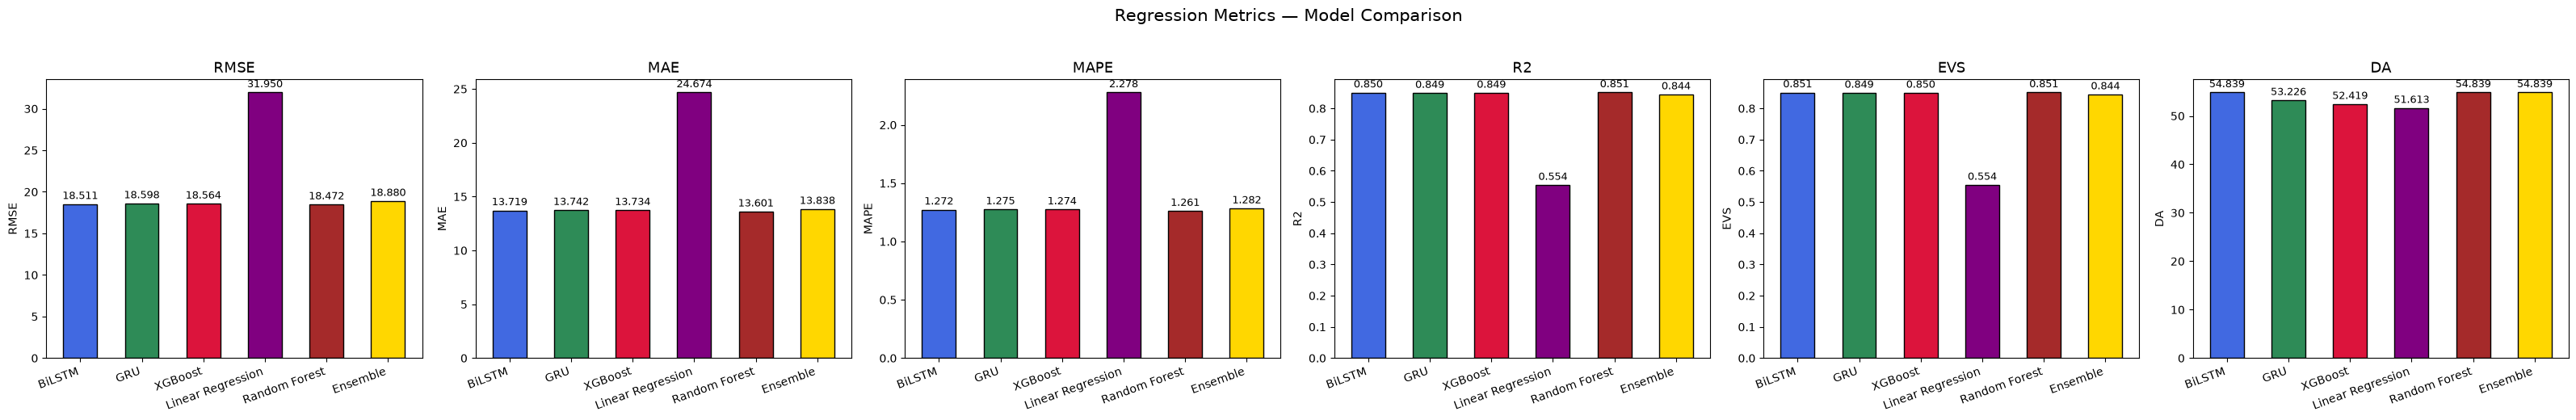

In [29]:
#VIZ-9

reg_df = pd.DataFrame(reg_results).T
colors = list(MODEL_COLORS.values())

fig, axes = plt.subplots(1, 6, figsize=(32, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE', 'R2', 'EVS', 'DA']):
    bars = ax.bar(reg_df.index, reg_df[metric],
                  color=colors, edgecolor='black', width=0.55)
    ax.set_title(f'{metric}', fontsize=13)
    ax.set_ylabel(metric)
    ax.set_xticklabels(reg_df.index, rotation=20, ha='right')
    for bar, val in zip(bars, reg_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Regression Metrics — Model Comparison', fontsize=15, y=1.03)
plt.tight_layout()
plt.savefig("plots/11_regression_metrics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
# 18.  SAVE MODELS

joblib.dump(model_lr, "models/model_linear_regression.pkl")
joblib.dump(model_rf, "models/model_random_forest.pkl")

print("\n" + "="*50)
print("  All models saved successfully!")
print("    models/best_bilstm.keras")
print("    models/best_gru.keras")
print("    models/best_xgb.json")
print("    models/model_linear_regression.pkl")
print("    models/model_random_forest.pkl")
print("="*50)


  All models saved successfully!
    models/best_bilstm.keras
    models/best_gru.keras
    models/best_xgb.json
    models/model_linear_regression.pkl
    models/model_random_forest.pkl
